In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
import warnings# 忽略所有警告
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

In [5]:
# 划分特征和目标变量
df = pd.read_csv(r'E:\9月\实验测试\130特征\130(saio_20211225_30)\139\S2Values_139.csv')
print(df.columns)

Index(['system:index', 'ARVI', 'CRSI', 'Clay', 'DVI', 'ENDVI', 'EVI', 'GDVI',
       'GRVI', 'LULC', 'MNDWI2', 'MSAVI', 'NDVI', 'NDWI', 'NLI', 'SAIO',
       'SAVI', 'SD', 'SI_T', 'SR', 'SRSI', 'VIopt', 'aet', 'aspect',
       'elevation', 'pH', 'pet', 'pr', 'slope', 't2m', '序号', '电导率', '纬度', '经度',
       '.geo'],
      dtype='object')


In [6]:
#删除多余的特征变量
X = df.drop(['序号','电导率','纬度','经度','.geo','system:index'], axis=1)
y = df['电导率']

In [2]:
#添加训练集和测试集
import geopandas as gpd
import numpy as np 
import pandas as pd 
import rasterio
import seaborn as sns
from matplotlib import cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE  
from sklearn.linear_model import LogisticRegression  
from sklearn.model_selection import train_test_split  
from sklearn.metrics import accuracy_score 
from sklearn import metrics
from scipy.stats import randint as sp_randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
data_s2_train = pd.read_csv(r"E:\大论文\sentinel-2\实验9\特征数据\S2_trainingData_RF.csv")
data_s2_test = pd.read_csv(r"E:\大论文\sentinel-2\实验9\特征数据\S2_validationData_RF.csv")

In [21]:
#排名前15特征获取
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(X_train, y_train)
# 提取特征重要性
feature_importance = rf_model.feature_importances_
# 构建特征重要性
feature_importance_df = pd.DataFrame({'Feature': X.columns,'Importance': feature_importance})
# 按重要性降序排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 获取排名前15的特征名称
top_15_features = feature_importance_df.head(15)

# 打印前15个特征
print(top_15_features)

   Feature  Importance
4    ENDVI    0.373268
16      SD    0.069177
9   MNDWI2    0.048974
24      pH    0.041086
28     t2m    0.038381
25     pet    0.036570
14    SAIO    0.034351
5      EVI    0.033338
21     aet    0.029935
13     NLI    0.029252
1     CRSI    0.028731
2     Clay    0.026337
20   VIopt    0.026126
3      DVI    0.025135
0     ARVI    0.018327


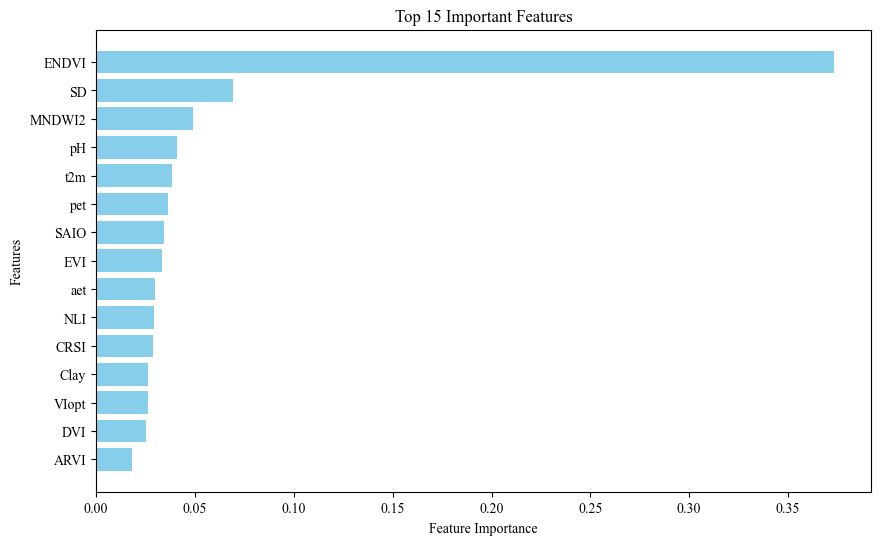

In [12]:
# 绘制特征重要性排名图
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Important Features')
plt.gca().invert_yaxis()  # 让重要性最高的特征排在最上面
plt.show()


In [55]:
import pandas as pd
import numpy as np

# 假设已经生成 feature_importance_df 和 top_15_features
# 提取前15个特征
top_15_features_names = top_15_features['Feature'].tolist()

# 从数据集中提取前15特征的值
top_15_features_data = X[top_15_features_names]

# 计算特征的皮尔逊相关系数矩阵
correlation_matrix = top_15_features_data.corr().abs()


# 设置相关性阈值
threshold = 0.9
selected_features = []  # 存储筛选后的特征

for feature in top_15_features_names:
    # 判断当前特征是否与已选择的特征高度相关
    is_highly_correlated = any(
        correlation_matrix.loc[feature, selected_feature] > threshold
        for selected_feature in selected_features
    )
    # 如果不相关，则加入最终选择的特征列表
    if not is_highly_correlated:
        selected_features.append(feature)

# 确保只选择 top_n 个特征
top_n = 10
selected_features = selected_features[:top_n]

# 打印最终筛选的特征
print(f"最终筛选的特征（{top_n}个）：", selected_features)

# 最终筛选的特征子集
X_selected = X[selected_features]



最终筛选的特征（10个）： ['ENDVI', 'SD', 'MNDWI2', 'pH', 't2m', 'pet', 'SAIO', 'EVI', 'aet', 'Clay']


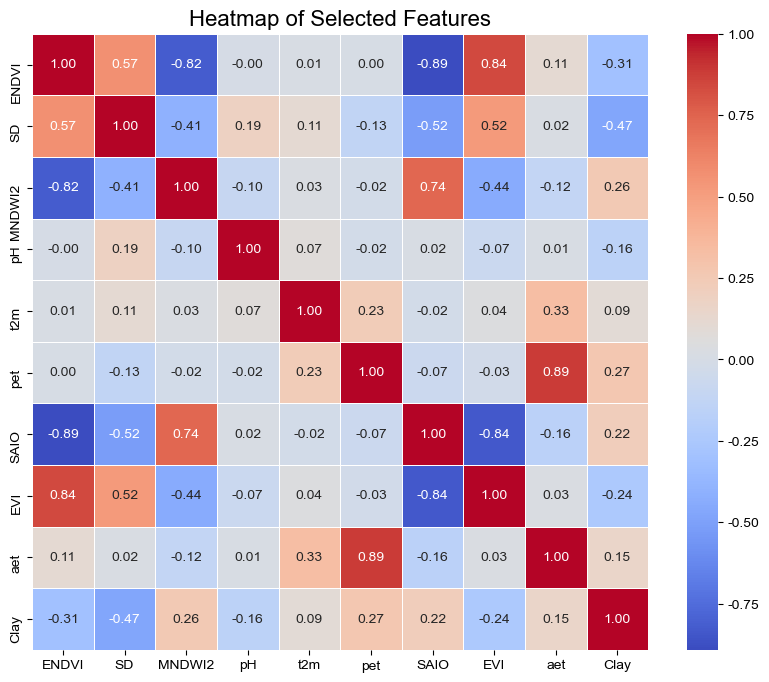

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置字体
plt.rcParams["font.family"] = "Arial"  # 设置为 Arial

# 提取最终筛选的特征子集
X_selected_data = X[selected_features]

# 重新计算筛选后特征的相关性矩阵
selected_correlation_matrix = X_selected_data.corr()

# 画热力图
plt.figure(figsize=(10, 8))  # 调整图大小
sns.heatmap(
    selected_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10},  # 调整字体大小
)
plt.title("Heatmap of Selected Features", fontsize=16)
plt.show()


Feature Names from top_15_features: ['ENDVI', 'SD', 'MNDWI2', 'pH', 't2m', 'pet', 'SAIO', 'EVI', 'aet', 'NLI', 'CRSI', 'Clay', 'VIopt', 'DVI', 'ARVI']
Selected Features after correlation filtering: ['ENDVI', 'SD', 'MNDWI2', 'pH', 't2m', 'pet', 'SAIO', 'EVI', 'aet', 'Clay']
Colors assignment check:
Feature: ENDVI, Color: red
Feature: SD, Color: red
Feature: MNDWI2, Color: red
Feature: pH, Color: red
Feature: t2m, Color: red
Feature: pet, Color: red
Feature: SAIO, Color: red
Feature: EVI, Color: red
Feature: aet, Color: red
Feature: NLI, Color: blue
Feature: CRSI, Color: blue
Feature: Clay, Color: red
Feature: VIopt, Color: blue
Feature: DVI, Color: blue
Feature: ARVI, Color: blue


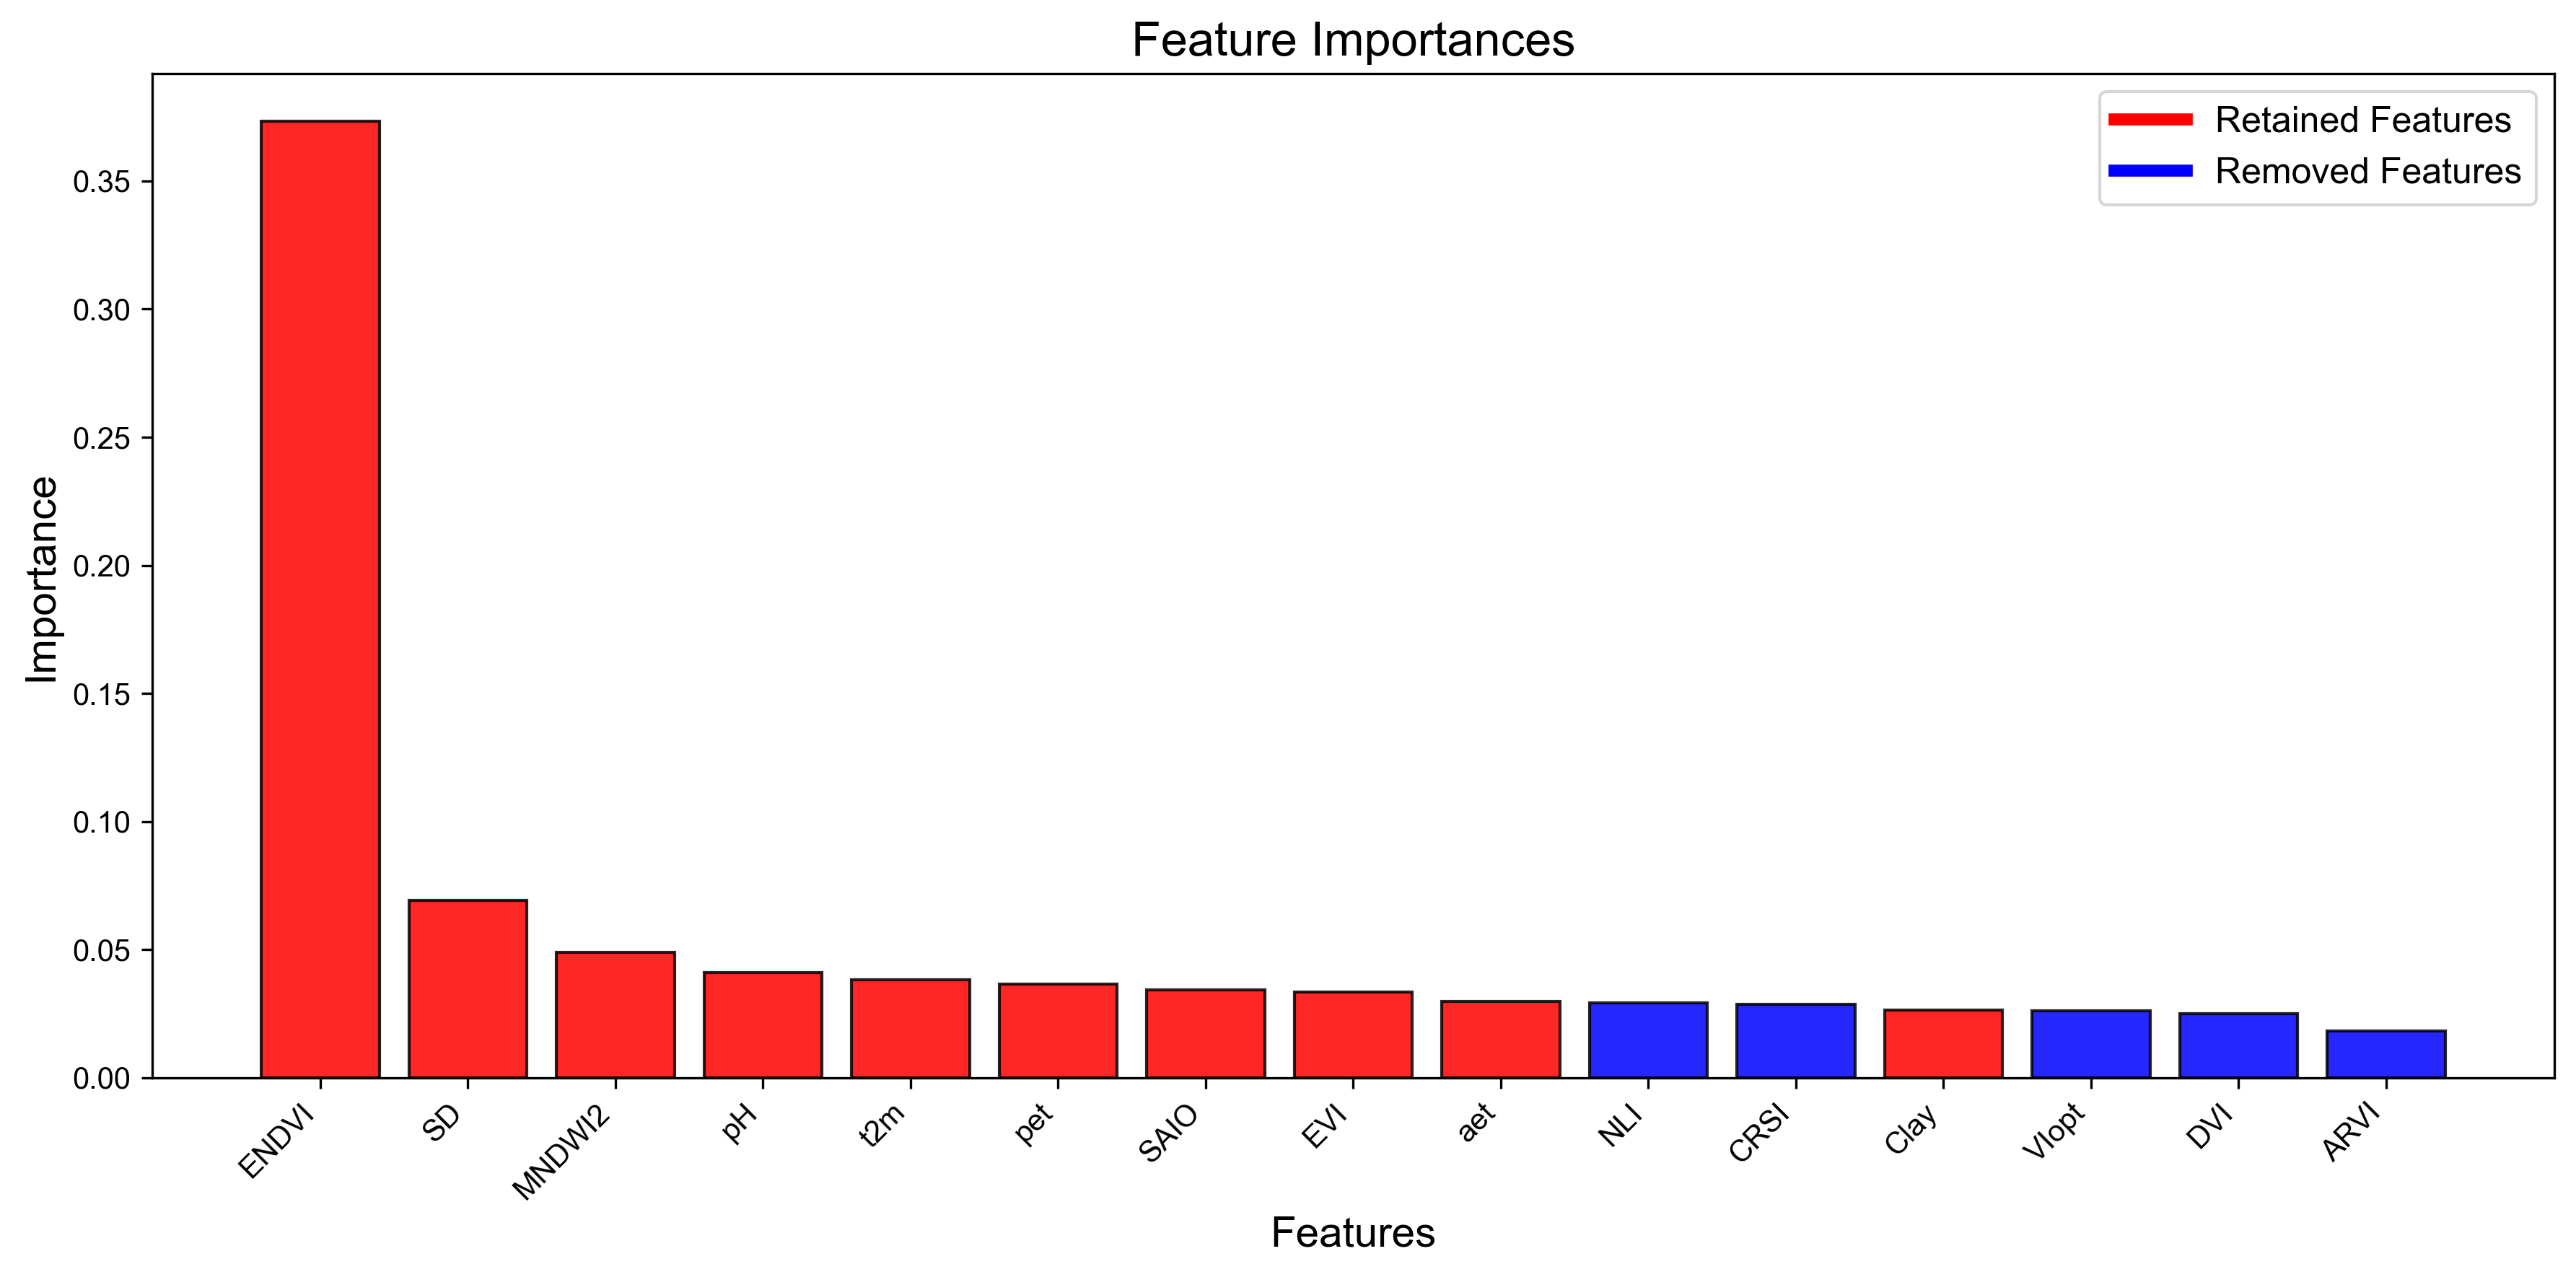

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 确保特征名称一致性
feature_names = top_15_features['Feature'].astype(str).str.strip()  # 保证一致性
feature_importances = top_15_features['Importance']
selected_features = [str(feature).strip() for feature in selected_features]  # 保留的特征

# 打印调试信息
print("Feature Names from top_15_features:", feature_names.tolist())
print("Selected Features after correlation filtering:", selected_features)

# 设置颜色：保留的特征为红色，剔除的特征为蓝色
colors = ['red' if feature in selected_features else 'blue' for feature in feature_names]

# 打印颜色匹配结果
print("Colors assignment check:")
for feature, color in zip(feature_names, colors):
    print(f"Feature: {feature}, Color: {color}")

# 创建柱状图
plt.figure(figsize=(12, 6), dpi=300)
bars = plt.bar(feature_names, feature_importances, color=colors, edgecolor='black', alpha=0.85)

# 添加图例
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Retained Features')  # 红色图例
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Removed Features')  # 蓝色图例
plt.legend(handles=[red_patch, blue_patch], loc='upper right', fontsize=12)

# 设置图形标题和标签
plt.title('Feature Importances', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Importance', fontsize=14)

# 调整 x 轴刻度标签显示
plt.xticks(rotation=45, fontsize=10, ha='right')

# 紧凑布局并保存图形
plt.tight_layout()
plt.savefig('feature_importances_corrected.png', format='png', bbox_inches='tight')
plt.show()

In [69]:
#穷举计算
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn import metrics
import matplotlib.pyplot as plt

# 检查并删除列
columns_to_drop = ['序号', '电导率', '纬度', '经度', '.geo', 'system:index']
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# 获取最终特征
X_selected = ['ENDVI', 'SD', 'MNDWI2', 'pH', 't2m', 'pet', 'SAIO', 'EVI', 'aet', 'Clay']  # 示例列名，需替换为实际列名
X = df.drop(columns_to_drop, axis=1)

from itertools import combinations
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor



# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 生成所有特征的组合，例如选择3个特征的组合
all_combinations = combinations(final_features, 3)

# 初始化结果存储
results = []

# 逐个特征组合建模并评估
for combination in all_combinations:
    selected_features = list(combination)
    X_train_subset = X_train[selected_features]
    X_test_subset = X_test[selected_features]
    
    # 创建随机森林模型（默认参数）
    rf_model = RandomForestRegressor(random_state=42)
    
    # 进行5折交叉验证，计算平均 R^2 分数
    cv_scores = cross_val_score(rf_model, X_train_subset, y_train, cv=5, scoring='r2')
    mean_cv_score = np.mean(cv_scores)
    
    # 记录结果
    results.append({
        'Features': selected_features,
        'Mean CV R^2': mean_cv_score
    })

# 将结果转换为 DataFrame 并按 R^2 分数排序
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Mean CV R^2', ascending=False).reset_index(drop=True)

# 打印结果
print(results_df)


             Features  Mean CV R^2
0    [ENDVI, SD, aet]     0.293811
1      [SD, t2m, aet]     0.289546
2    [ENDVI, SD, pet]     0.288167
3      [SD, t2m, pet]     0.264763
4     [SD, aet, Clay]     0.254348
..                ...          ...
115   [pH, SAIO, EVI]    -0.089563
116  [t2m, SAIO, EVI]    -0.099545
117   [pH, aet, Clay]    -0.159281
118   [pH, pet, Clay]    -0.277635
119    [pH, pet, aet]    -0.323791

[120 rows x 2 columns]


In [ ]:
# 最佳特征组合
best_features = results_df.iloc[0]['Features']
X = df[best_features]
y = df['Tensile strength/MPa']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 网格搜索超参数调优
param_grid = {
    'n_estimators': [50, 80],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

cv = KFold(n_splits=10, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# 使用最佳参数训练模型
rf_model = grid_search.best_estimator_

# 模型预测与评估
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 计算指标
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
r2_train = metrics.r2_score(y_train, y_pred_train)

mse_test = metrics.mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
r2_test = metrics.r2_score(y_test, y_pred_test)

# 打印结果
print("训练集评价指标:")
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("R²:", r2_train)

print("\n测试集评价指标:")
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("R²:", r2_test)

# 可视化预测结果
plt.figure(figsize=(8, 8), dpi=300)
plt.scatter(y_test, y_pred_test, alpha=0.6, label='Test Data', color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2, label='Ideal Line (y=x)')
plt.title('Prediction vs Actual', fontsize=16)
plt.xlabel('Actual Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_vs_actual.png', bbox_inches='tight')
plt.show()